NLA round-trip accuracy degradation experiment.

Idea: patch a single token's activation at a single layer with its
NLA round-trip reconstruction 
$$
(h -> AV(h) -> text -> AR(text) -> h_hat)
$$
then let generation continue normally. Compare downstream task accuracy
against (a) an unpatched baseline and (b) a no-op patch control that
re-injects the *original* activation unchanged.

This script assumes you have:
  - a HF-loadable Gemma model (`MODEL_NAME`)
  - your own trained AV and AR modules from natural_language_autoencoders,
    exposed as callables: av(h_vec) -> str, ar(text) -> torch.Tensor
  - GSM8K test split via `datasets`

Fill in the two TODOs (load_av_ar, extract_final_answer) for your repo's
actual API / answer-parsing format before running.

## Experiment Overview

All experiments share one AV server and use the same target tokenizer/model state where possible. The notebook deliberately unloads the 27B target before loading the AR, then reloads the target for introspection, so the full target and AR do not coexist on the notebook GPU.

Results are printed and displayed near the cells that produce them. Round-trip and paraphrasing summaries are also written beneath the configurable experiment output root; introspection and zero-vector results remain notebook-only.

In [1]:
from __future__ import annotations

# -----------------------------------------------------------------------------
# EDIT THESE VALUES FOR YOUR CLUSTER ALLOCATION
# -----------------------------------------------------------------------------
# USER_NAME is your Linux username / /home folder name.
# VISIBLE_GPUS are the physical GPU IDs assigned to you, comma-separated.
# After CUDA masking, the first listed physical GPU becomes cuda:0 in this notebook.
# SGLANG_PHYSICAL_GPU is the physical GPU reserved for the SGLang AV server.
USER_NAME = "kaylee"
VISIBLE_GPUS = "0,1"
SGLANG_PHYSICAL_GPU = "1"
LOCAL_DEVICE = "cuda:0"
# -----------------------------------------------------------------------------

# Run this notebook from a fresh kernel. CUDA_VISIBLE_DEVICES must be set before
# importing torch, so this setup cell intentionally defines paths/GPUs first.
import os
from pathlib import Path

HOME = Path("/home") / USER_NAME
NLA_REPO = Path(os.environ.get("NLA_REPO", HOME / "natural_language_autoencoders"))
SGLANG_REPO = Path(os.environ.get("SGLANG_REPO", HOME / "sglang"))
VENV_PYTHON = Path(os.environ.get("NLA_VENV_PYTHON", NLA_REPO / ".venv/bin/python"))
HF_CACHE = Path(os.environ.get("HF_HOME", HOME / ".cache/huggingface"))
ROOT = Path(os.environ.get("NLA_EXPERIMENT_ROOT", HOME / "experiments/nla_experiments"))
LIBNUMA_DIR = Path(
    os.environ.get(
        "NLA_LIBNUMA_DIR", NLA_REPO / "vendor/libnuma/usr/lib/x86_64-linux-gnu"
    )
)
PYTHON_INCLUDE_DIRS = [
    Path(
        os.environ.get(
            "NLA_PYTHON_INCLUDE",
            NLA_REPO / "vendor/python3.10-dev/usr/include/python3.10",
        )
    ),
    Path(
        os.environ.get(
            "NLA_PYTHON_MULTIARCH_INCLUDE",
            NLA_REPO / "vendor/python3.10-dev/usr/include",
        )
    ),
]
ROOT.mkdir(parents=True, exist_ok=True)


os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = VISIBLE_GPUS
os.environ["HF_HOME"] = str(HF_CACHE)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
if LIBNUMA_DIR.exists():
    os.environ["LD_LIBRARY_PATH"] = (
        f"{LIBNUMA_DIR}:{os.environ.get('LD_LIBRARY_PATH', '')}"
    )
_existing_cpath = os.environ.get("CPATH", "")
_include_paths = [str(path) for path in PYTHON_INCLUDE_DIRS if path.exists()]
if _include_paths:
    os.environ["CPATH"] = ":".join([*_include_paths, _existing_cpath])

import gc
import math
import random
import re
import subprocess
import time
from contextlib import contextmanager
from typing import Any

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from huggingface_hub import snapshot_download
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed

# Local NLA inference helpers from the released repo.
import sys

sys.path.insert(0, str(NLA_REPO))
from nla_inference import NLAClient, NLACritic

TARGET_MODEL = "google/gemma-3-27b-it"
ACTOR_REPO_ID = os.environ.get("NLA_ACTOR_DIR", "kitft/nla-gemma3-27b-L41-av")
AR_REPO_ID = os.environ.get("NLA_AR_DIR", "kitft/nla-gemma3-27b-L41-ar")
SGLANG_URL = os.environ.get("SGLANG_URL", "http://127.0.0.1:30000")
SGLANG_LOG = Path.home() / "logs" / "sglang_av_server.log"
SGLANG_LOG.parent.mkdir(parents=True, exist_ok=True)
LAYER_INDEX = 41
DEVICE = LOCAL_DEVICE
SEED = 1234
N_EXAMPLES = 200


def resolve_checkpoint(path_or_repo_id: str) -> str:
    """Return a local checkpoint path with nla_meta.yaml available."""
    candidate = Path(path_or_repo_id).expanduser()
    if candidate.exists():
        assert (
            candidate / "nla_meta.yaml"
        ).exists(), f"Missing nla_meta.yaml in {candidate}"
        return str(candidate)
    local_path = Path(snapshot_download(repo_id=path_or_repo_id))
    assert (
        local_path / "nla_meta.yaml"
    ).exists(), f"Missing nla_meta.yaml in downloaded snapshot {local_path}"
    return str(local_path)


ACTOR_DIR = resolve_checkpoint(ACTOR_REPO_ID)
AR_DIR = resolve_checkpoint(AR_REPO_ID)

assert NLA_REPO.exists(), f"Missing NLA repo: {NLA_REPO}"
assert SGLANG_REPO.exists(), f"Missing patched SGLang checkout: {SGLANG_REPO}"
assert VENV_PYTHON.exists(), f"Missing NLA venv Python: {VENV_PYTHON}"

print("home:", HOME)
print("NLA repo:", NLA_REPO)
print("SGLang checkout:", SGLANG_REPO)
print("HF cache:", HF_CACHE)
print("experiment output:", ROOT)
print("vendored libnuma:", LIBNUMA_DIR if LIBNUMA_DIR.exists() else "not found")
print("vendored Python includes:", [p for p in PYTHON_INCLUDE_DIRS if p.exists()])
print("visible physical GPUs:", VISIBLE_GPUS)
print("SGLang physical GPU:", SGLANG_PHYSICAL_GPU)
print("notebook device:", DEVICE)
print("actor checkpoint:", ACTOR_DIR)
print("AR checkpoint:", AR_DIR)
print(torch.__version__, torch.cuda.is_available())
if torch.cuda.is_available():
    print("visible cuda devices:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"cuda:{i}", torch.cuda.get_device_name(i))

Fetching 38 files:   0%|          | 0/38 [00:00<?, ?it/s]

Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

home: /home/kaylee
NLA repo: /home/kaylee/natural_language_autoencoders
SGLang checkout: /home/kaylee/sglang
HF cache: /home/kaylee/.cache/huggingface
experiment output: /home/kaylee/experiments/nla_experiments
vendored libnuma: /home/kaylee/natural_language_autoencoders/vendor/libnuma/usr/lib/x86_64-linux-gnu
vendored Python includes: []
visible physical GPUs: 0,1
SGLang physical GPU: 1
notebook device: cuda:0
actor checkpoint: /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-av/snapshots/4e721238131ffb8348cff260fe81b8b34a270a0d
AR checkpoint: /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-ar/snapshots/aa2f29723c4807caf5f665dac004998df71b7cfb
2.9.1+cu128 True
visible cuda devices: 2
cuda:0 NVIDIA A100-SXM4-80GB
cuda:1 NVIDIA A100-SXM4-80GB


In [2]:
import os

UV_PYTHON_INCLUDE = "/home/kaylee/.local/share/uv/python/cpython-3.10.20-linux-x86_64-gnu/include/python3.10"
assert os.path.exists(os.path.join(UV_PYTHON_INCLUDE, "Python.h")), "Python.h not found at that path"

os.environ["CPATH"] = f"{UV_PYTHON_INCLUDE}:{os.environ.get('CPATH', '')}"
print("CPATH now:", os.environ["CPATH"])

REAL_LIBNUMA_DIR = "/home/kaylee/.local/lib"
assert os.path.exists(os.path.join(REAL_LIBNUMA_DIR, "libnuma.so.1")), "libnuma.so.1 not found there"

os.environ["LD_LIBRARY_PATH"] = f"{REAL_LIBNUMA_DIR}:{os.environ.get('LD_LIBRARY_PATH', '')}"
print("LD_LIBRARY_PATH now:", os.environ["LD_LIBRARY_PATH"])

CPATH now: /home/kaylee/.local/share/uv/python/cpython-3.10.20-linux-x86_64-gnu/include/python3.10:
LD_LIBRARY_PATH now: /home/kaylee/.local/lib:/home/kaylee/natural_language_autoencoders/vendor/libnuma/usr/lib/x86_64-linux-gnu:/home/kaylee/.local/lib:


In [3]:
!rm -rf ~/.triton/cache

In [4]:
import os
print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH"))
print("CPATH:", os.environ.get("CPATH"))

LD_LIBRARY_PATH: /home/kaylee/.local/lib:/home/kaylee/natural_language_autoencoders/vendor/libnuma/usr/lib/x86_64-linux-gnu:/home/kaylee/.local/lib:
CPATH: /home/kaylee/.local/share/uv/python/cpython-3.10.20-linux-x86_64-gnu/include/python3.10:


## Start The AV Server

The AV uses SGLang because the checkpoint expects `input_embeds` injection. This notebook launches the patched editable SGLang checkout through the NLA `.venv`, pinned to the physical GPU chosen in the setup cell.



In [5]:
def launch_sglang_actor() -> subprocess.Popen:
    env = os.environ.copy()
    env["HF_HOME"] = str(HF_CACHE)
    env["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    env["CUDA_VISIBLE_DEVICES"] = SGLANG_PHYSICAL_GPU
    env["SGLANG_MIN_NEW_TOKEN_RATIO_FACTOR"] = "1"
    env["PYTHONPATH"] = f"{NLA_REPO}:{env.get('PYTHONPATH', '')}"
    if LIBNUMA_DIR.exists():
        env["LD_LIBRARY_PATH"] = f"{LIBNUMA_DIR}:{env.get('LD_LIBRARY_PATH', '')}"
    include_paths = [str(path) for path in PYTHON_INCLUDE_DIRS if path.exists()]
    if include_paths:
        env["CPATH"] = ":".join([*include_paths, env.get("CPATH", "")])

    cmd = [
        str(VENV_PYTHON),
        "-m",
        "sglang.launch_server",
        "--model-path",
        ACTOR_DIR,
        "--port",
        "30000",
        "--host",
        "127.0.0.1",
        "--disable-radix-cache",
        "--mem-fraction-static",
        "0.80",
        "--context-length",
        "512",
        "--attention-backend",
        "triton",
        "--disable-cuda-graph",
        "--trust-remote-code",
        "--log-level",
        "warning",
    ]
    print("Launching SGLang on physical GPU", SGLANG_PHYSICAL_GPU)
    print(" ".join(cmd))
    print("SGLang server logs ->", SGLANG_LOG)
    log_f = open(SGLANG_LOG, "ab", buffering=0)
    return subprocess.Popen(
        cmd, env=env, cwd=str(NLA_REPO), stdout=log_f, stderr=subprocess.STDOUT
    )


def sglang_is_healthy() -> bool:
    import urllib.request

    try:
        urllib.request.urlopen(SGLANG_URL + "/health", timeout=2).read()
        return True
    except Exception:
        return False


def wait_for_sglang(timeout_s: int = 300) -> None:
    deadline = time.time() + timeout_s
    last_error = None
    while time.time() < deadline:
        if sglang_is_healthy():
            print("SGLang is healthy")
            return
        try:
            import urllib.request

            urllib.request.urlopen(SGLANG_URL + "/health", timeout=2).read()
        except Exception as exc:
            last_error = exc
        time.sleep(2)
    raise TimeoutError(f"SGLang did not become healthy: {last_error!r}")


sglang_proc = None
if sglang_is_healthy():
    print("SGLang is already healthy at", SGLANG_URL)
else:
    sglang_proc = launch_sglang_actor()
    wait_for_sglang()

Launching SGLang on physical GPU 1
/home/kaylee/natural_language_autoencoders/.venv/bin/python -m sglang.launch_server --model-path /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-av/snapshots/4e721238131ffb8348cff260fe81b8b34a270a0d --port 30000 --host 127.0.0.1 --disable-radix-cache --mem-fraction-static 0.80 --context-length 512 --attention-backend triton --disable-cuda-graph --trust-remote-code --log-level warning
SGLang server logs -> /home/kaylee/logs/sglang_av_server.log


SGLang is healthy


# Experiment 1

In [6]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

tokenizer = AutoTokenizer.from_pretrained(TARGET_MODEL, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    TARGET_MODEL, torch_dtype=torch.bfloat16, device_map={"": DEVICE},
    trust_remote_code=True, attn_implementation="eager",
).eval()
del model.model.vision_tower
gc.collect()
torch.cuda.empty_cache()
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/12 [00:00<?, ?it/s]

In [7]:
print("model" in globals())
if "model" in globals():
    print(model.device if hasattr(model, "device") else next(model.parameters()).device)

True
cuda:0


In [8]:
client = NLAClient(ACTOR_DIR, sglang_url=SGLANG_URL)
critic = NLACritic(AR_DIR, device="cpu", dtype=torch.float32)
print("Target and AV client ready")


[NLAClient] 4e721238131ffb8348cff260fe81b8b34a270a0d: d_model=5376 inj_scale=60000.0 embed_scale=73.32 inj_char='㈜'(id=246566)


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Some weights of Gemma3ForCausalLM were not initialized from the model checkpoint at /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-ar/snapshots/aa2f29723c4807caf5f665dac004998df71b7cfb and are newly initialized: ['model.norm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[NLACritic] 42 layers  d_model=5376  mse_scale=73.32
Target and AV client ready


In [9]:
N_SANITY = 10
MAX_NEW_TOKENS = 256

def av(h: torch.Tensor) -> str:
    v = h.detach().float().cpu().numpy()
    return client.generate(v, temperature=0.0, max_new_tokens=MAX_NEW_TOKENS, extract_explanation=True)

def ar(text: str) -> torch.Tensor:
    return critic.reconstruct(text)  # raw, unnormalized -- matches h's scale


# --- Patch hook: replace the residual stream at the last prompt token ---
class LastTokenPatcher:
    def __init__(self, patch_vec=None):
        self.patch_vec = patch_vec
        self.captured = None
        self._done = False  # only patch once

    def __call__(self, module, inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        # Only act on the initial multi-token prefill pass, not each
        # single-token decode step that follows.
        if hidden.shape[1] > 1 and not self._done:
            self.captured = hidden[0, -1, :].detach().clone()
            if self.patch_vec is not None:
                hidden = hidden.clone()
                hidden[0, -1, :] = self.patch_vec.to(hidden.dtype).to(hidden.device)
                self._done = True
                return (hidden,) + output[1:] if isinstance(output, tuple) else hidden
            self._done = True
        return output

def mse_cos_from_reconstruction(h_hat: torch.Tensor, h_orig: torch.Tensor, mse_scale: float):
    pred = h_hat.float()
    gold = h_orig.float().cpu()
    pred_n = pred / pred.norm().clamp_min(1e-12) * mse_scale
    gold_n = gold / gold.norm().clamp_min(1e-12) * mse_scale
    mse = ((pred_n - gold_n) ** 2).mean().item()
    cos = (pred_n @ gold_n / (pred_n.norm() * gold_n.norm())).item()
    return mse, cos

def get_layer_module(m, layer_idx):
    return m.model.language_model.layers[layer_idx]


def run_with_patch(prompt: str, patch_vec, max_new_tokens=256):
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    patcher = LastTokenPatcher(patch_vec)
    handle = get_layer_module(model, LAYER_INDEX).register_forward_hook(patcher)
    try:
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    finally:
        handle.remove()
    text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return text, patcher.captured


# --- Run the three-condition comparison on a GSM8K subset ---
import re
from datasets import load_dataset

def extract_final_answer(text: str):
    m = re.search(r"[-+]?\d[\d,]*\.?\d*", text.strip().split("\n")[-1])
    return m.group().replace(",", "") if m else None

def gsm8k_gold(ex):
    return ex["answer"].split("####")[-1].strip().replace(",", "")

ds = load_dataset("gsm8k", "main", split="test").select(range(N_SANITY))
correct = {"baseline": 0, "nla_roundtrip": 0}
mse_list, cos_list = [], []
nla_correct_list = []

for i, ex in enumerate(ds):
    print(f"[{i+1}/{N_SANITY}] processing...")
    prompt = ex["question"] + "\nAnswer: Let's think step by step."
    gold = gsm8k_gold(ex)

    text_base, h_orig = run_with_patch(prompt, patch_vec=None, max_new_tokens=MAX_NEW_TOKENS)
    correct["baseline"] += extract_final_answer(text_base) == gold

    explanation = av(h_orig)
    h_hat = ar(explanation)
    mse, cos = mse_cos_from_reconstruction(h_hat, h_orig, critic.mse_scale)
    mse_list.append(mse); cos_list.append(cos)

    text_nla, _ = run_with_patch(prompt, patch_vec=h_hat, max_new_tokens=MAX_NEW_TOKENS)
    is_correct = extract_final_answer(text_nla) == gold
    nla_correct_list.append(is_correct) 
    correct["nla_roundtrip"] += extract_final_answer(text_nla) == gold

n = N_SANITY
print(f"Baseline:       {correct['baseline']/n:.2%}")
print(f"NLA round-trip: {correct['nla_roundtrip']/n:.2%}")
print(f"Mean cos-sim: {sum(cos_list)/len(cos_list):.3f}  (mean MSE: {sum(mse_list)/len(mse_list):.3f})")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[1/10] processing...
[2/10] processing...
[3/10] processing...
[4/10] processing...
[5/10] processing...
[6/10] processing...
[7/10] processing...
[8/10] processing...
[9/10] processing...
[10/10] processing...
Baseline:       100.00%
NLA round-trip: 90.00%
Mean cos-sim: 0.992  (mean MSE: 0.017)


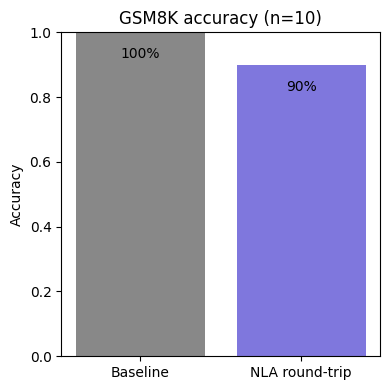

In [10]:
labels = ["Baseline", "NLA round-trip"]
values = [correct["baseline"]/n, correct["nla_roundtrip"]/n]

plt.figure(figsize=(4,4))
plt.bar(labels, values, color=["#888", "#7F77DD"])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(values):
    plt.text(i, v - 0.08, f"{v:.0%}", ha="center")
plt.title(f"GSM8K accuracy (n={n})")
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

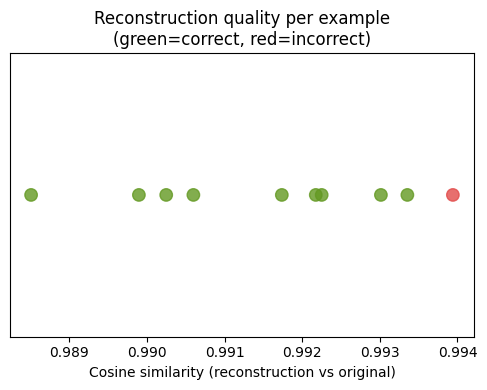

In [11]:
plt.figure(figsize=(5,4))
colors = ["#639922" if c else "#E24B4A" for c in nla_correct_list]
plt.scatter(cos_list, [1]*len(cos_list), c=colors, s=80, alpha=0.8)
plt.yticks([])
plt.xlabel("Cosine similarity (reconstruction vs original)")
plt.title("Reconstruction quality per example\n(green=correct, red=incorrect)")
plt.tight_layout()
plt.savefig("cos_vs_correctness.png", dpi=150)
plt.show()

## Cleanup

Close the AV client's HTTP session and stop SGLang only if this notebook launched it. An AV server that was already running before the notebook is left untouched.


In [ ]:
if "client" in globals() and hasattr(client, "_http"):
    client._http.close()
    print("Closed NLA client HTTP session")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

if "sglang_proc" in globals() and sglang_proc is not None:
    sglang_proc.terminate()
    sglang_proc.wait(timeout=30)
    print("Stopped SGLang launched by this notebook")
else:
    print("No SGLang subprocess launched by this notebook")

# Optional final memory check:
# !nvidia-smi

Closed NLA client HTTP session
No SGLang subprocess launched by this notebook
